# 03 평가
- 분류의 평가 지표
    - 정확도
    - 오차행렬
    - 정밀도
    - 재현율
    - F1스코어
    - ROC AUC
- 결정 클래스 값 종류의 유형에 따라 나뉘는 분류
    - 이진 분류 : 긍정/부정과 같은 두개의 결과값만을 가짐
    - 멀티 분류 : 여러 개의 결정 클래스 값을 가짐





## 01 정확도
- 정확도 : 모델 예측 성능을 나타내는 평가 지표
    - 정확도 = 예측 결과가 동일한 데이터 건수 / 전체 예측 데이터 건수


In [55]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Null 처리 함수
def fillna(df):
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    df['Cabin'].fillna('N', inplace=True)
    df['Embarked'].fillna('N', inplace=True)
    df['Fare'].fillna(0, inplace=True)
    return df

# 머신러닝 알고리즘에 불필요한 피처 제거
def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df

# 레이블 인코딩 수행.
def format_features(df):
    df['Cabin'] = df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

# 앞에서 설정한 데이터 전처리 함수 호출
def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

In [56]:
from sklearn.base import BaseEstimator

class MyDummyClassifier(BaseEstimator):
    # fit( ) 메서드는 아무것도 학습하지 않음.
    def fit(self, X, y=None):
        pass
    # predict( ) 메서드는 단순히 Sex 피처가 1이면 0, 그렇지 않으면 1로 예측함.
    def predict(self, X):
        pred = np.zeros( ( X.shape[0], 1))
        for i in range (X.shape[0]) :
            if X['Sex'].iloc[i] == 1:
                pred[i] = 0
            else :
                pred[i] = 1

        return pred

In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 원본 데이터를 재로딩, 데이터 가공, 학습 데이터/테스트 데이터 분할.
titanic_df = pd.read_csv('./titanic_train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df= titanic_df.drop('Survived', axis=1)
X_titanic_df = transform_features(X_titanic_df)
X_train, X_test, y_train, y_test=train_test_split(X_titanic_df, y_titanic_df,
                                                  test_size=0.2, random_state=0)

# 위에서 생성한 Dummy Classifier를 이용해 학습/예측/평가 수행.
myclf = MyDummyClassifier()

myclf.fit(X_train, y_train)

mypredictions = myclf.predict(X_test)
print('Dummy Classifier의 정확도는: {0:.4f}'.format(accuracy_score(y_test, mypredictions)))

Dummy Classifier의 정확도는: 0.7877


/var/folders/w6/fhx2fj2d3t717fvxsdxb48180000gn/T/ipykernel_65032/3007827293.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/var/folders/w6/fhx2fj2d3t717fvxsdxb48180000gn/T/ipykernel_65032/3007827293.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

- 위와 같이 단순한 알고리즘으로 예측하더라도 데이터의 구성에 따라 정확도 결과는 약 78.77%로 꽤 높은 수치가 나올 수 있음
=> 정확도를 평가 지표로 사용할 때는 매우 신중해야함
- 특히 불균형한 레이블 값 분포에서 ML모델의 성능을 판단할 경우, 적합한 평가지표가 아님
ex) 100개의 데이터 이중 90개의 데이터 레이블 0, 10개의 데이터 레이블 1이라고 한다면 무조건 0으로 예측 결과 반환하더라도 정확도 90%

#### MNIST 데이터세트
- 0부터 9까지의 숫자 이미지의 픽셀 정보, 이를 기반으로 숫자 Digit를 예측하는데 사용
- 원래 MNIST 데이터 세트는 레이블 값이 0부터 9까지 있는 멀티 레이블 분류를 위한 것
- 레이블 값이 7인 것만 True, 나머지 값은 모두 Falsse로 변환해 이진 분류 문제로 바꿈
- 즉, 전체 데이터의 10%만 True, 나머지 90%는 False인 불균형한 데이터 세트로 변형
=> predict() 의 결과를 np.zeros()로 모두 0값으로 반환함에도 정확도는 90%

- 정확도 평가지표는 불균형한 레이블 데이터 세트에서는 성능수치로 사용해서는 안됨
=> 여러가지 분류지표와 함께 적용하여 ML 모델 성능 평가해야함


In [58]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

class MyFakeClassifier(BaseEstimator):
    def fit(self, X, y):
        pass

    # 입력값으로 들어오는 X 데이터 세트의 크기만큼 모두 0값으로 만들어서 반환
    def predict(self, X):
        return np.zeros( (len(X), 1), dtype=bool) # dtype=bool: 이 0들을 False로 표현하겠다는 뜻 (0=False, 1=True는 같은 값이라 결과는 동일함)

# 사이킷런의 내장 데이터 세트인 load_digits( )를 이용해 MNIST 데이터 로딩
digits = load_digits()

# digits 번호가 7번이면 True이고 이를 astype(int)로 1로 변환, 7번이 아니면 False이고 0으로 변환.
y = (digits.target == 7).astype(int)
X_train, X_test, y_train, y_test = train_test_split( digits.data, y, random_state=11)

In [59]:
# 불균형한 레이블 데이터 분포도 확인.
print('레이블 테스트 세트 크기 :', y_test.shape)
print('테스트 세트 레이블 0 과 1의 분포도')
print(pd.Series(y_test).value_counts())

# Dummy Classifier로 학습/예측/정확도 평가
fakeclf = MyFakeClassifier()
fakeclf.fit(X_train, y_train)
fakepred = fakeclf.predict(X_test)
print('모든 예측을 0으로 하여도 정확도는:{:.3f}'.format(accuracy_score(y_test, fakepred)))

레이블 테스트 세트 크기 : (450,)
테스트 세트 레이블 0 과 1의 분포도
0    405
1     45
Name: count, dtype: int64
모든 예측을 0으로 하여도 정확도는:0.900


## 02 오차행렬
- 오차행렬 : 이진 분류의 예측 오류가 얼마인지 + 어떠한 유형의 예측 오류가 발생하고 있는지 함께 나타내는 지표
- 4분면의 왼쪽, 오른쪽을 예측된 클래스 값 기준으로 Negative와 Positive로 분류
- 4분면의 위, 아래를 실제 클래스 값 기준으로 Negative와 Positive로 분류
=> TN, FP, FN, TP
- 앞문자 True/False는 예측값이 실제값과 '같은가/틀린가' 의미
- 뒤 문자 Negative/Positive 는 예측 결과 값이 부정(0)/긍정(1) 의미
- confusion_matrix() : 오차행렬을 구하기 위한 API
- 오차행렬 상의 정확도 = (TN+TP)/(TN+FP+FN+TP)

In [60]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, fakepred)

array([[405,   0],
       [ 45,   0]])

- 불균형한 데이터 레이블 가지는 경우 중점적으로 찾아야 하는 매우 적은 수의 결괏값에 Positive를 설정해 1값 부여, 그렇지 않은 경우 Negative로 0값 부여
    - ex) 사기 행위 예측 모델(사기행위:1/정상행위:0), 암 검진 예측 모델(양성:1/음성:0) 할당
- Positive 데이터 건수 매우 작기 때문에 Positive보다 Negative로 예측 정확도가 높아지는 경향 발생
    - ex) 10000건의 데이터 세트에서 9900 건이 Negative, 100건 Positive 데이터 => TN 커지고 TP 매우 작아짐
- Negative로 예측할 때 정확도가 높기 때문에 FN이 매우 작고 Positive로 예측하는 경우가 작기 때문에 FP 매우 작음




## 03 정밀도와 재현율
- 정밀도와 재현율은 Positive 데이터 세트의 예측 성능에 좀 더 초점을 맞춘 평가 지표
ex) MyFakeClassifier는 Positive로 예측한 TP값이 하나도 없기 때문에 정밀도와 재현율 값이 모두 0
- 정밀도 = TP / (FP + TP)
    - 예측을 Positive로 한 대상 중에 예측과 실제 값이 Positive로 일치한 데이터의 비율(양성 에측도)
- 재현율 = TP / (FN + TP)
    - 실제 값이 Positive인 대상 중에 예측과 실제 값이 Positive로 일치한 데이터의 비율(민감도)
- 재현율이 중요 지표인 경우 : 실제 Positive 양성 데이터를 Negative로 잘못 판단하게 되면 업무상 큰 영향이 발생하는 경우
ex) 암 판단 모델, 금융 사기 적발 모델
- 정밀도가 중요한 지표인 경우 : 실제 Negative 음성 데이터 예측을 Positive로 잘못 판단하게 되면 업무상 큰 영향이 발생 하는 경우
ex) 스펨 메일 판단하는 경우
- precision_score : 정밀도 계산 API
- recall_score() : 재현율 계산 API
- get_clf_eval() : confusion matrix, accuracy, precision, recall 평가 한번에 호출


In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def get_clf_eval(y_test, pred):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}'.format(accuracy, precision, recall))

In [62]:
# 로지스틱 회귀 기반으로 타이타닉 생존자를 예측하고 confusion matrix, accuracy, precision, recall 평가를 수행함.
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 원본 데이터를 재로딩, 데이터 가공, 학습 데이터/테스트 데이터 분할.
titanic_df = pd.read_csv('./titanic_train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df= titanic_df.drop('Survived', axis=1)
X_titanic_df = transform_features(X_titanic_df)

X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df,
                                                      test_size=0.20, random_state=11)
lr_clf = LogisticRegression(solver='liblinear')

lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
get_clf_eval(y_test, pred)

오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705


/var/folders/w6/fhx2fj2d3t717fvxsdxb48180000gn/T/ipykernel_65032/3007827293.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/var/folders/w6/fhx2fj2d3t717fvxsdxb48180000gn/T/ipykernel_65032/3007827293.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

#### 정밀도/재현율 트레이드오프
- 정밀도, 재현율이 강조되어야할 경우 분류의 결정 임곗값 조정해 정밀도 또는 재현율의 수치 높일 수 있음
- 그러나 한쪽이 올라가면 한쪽은 떨어지기 쉬움
- 사이킷런의 분류 알고리즘은 예측 데이터가 특정 레이블에 속하는지를 계산하기 위해 먼저 개별 레이블별로 결정확률 구함
-> 예측 확률이 큰 레이블값으로 예측
- 일반적으로 이진분류에서는 임곗값을 50%로 정하고 이 기준값보다 크면 Positive, 작으면 Negative로 결정
- predict_proba() : 개별 데이터별로 예측 확률을 반환하는 메서드




In [63]:
pred_proba = lr_clf.predict_proba(X_test)
pred  = lr_clf.predict(X_test)
print('pred_proba()결과 Shape : {0}'.format(pred_proba.shape))
print('pred_proba array에서 앞 3개만 샘플로 추출 \n:', pred_proba[:3])

# 예측 확률 array와 예측 결괏값 array를 병합(concatenate)해 예측 확률과 결괏값을 한눈에 확인
pred_proba_result = np.concatenate([pred_proba, pred.reshape(-1, 1)], axis=1)
print('두 개의 class 중에서 더 큰 확률을 클래스 값으로 예측 \n', pred_proba_result[:3])

pred_proba()결과 Shape : (179, 2)
pred_proba array에서 앞 3개만 샘플로 추출 
: [[0.44935225 0.55064775]
 [0.86335511 0.13664489]
 [0.86429643 0.13570357]]
두 개의 class 중에서 더 큰 확률을 클래스 값으로 예측 
 [[0.44935225 0.55064775 1.        ]
 [0.86335511 0.13664489 0.        ]
 [0.86429643 0.13570357 0.        ]]


In [64]:
# fit_transform() 메서드를 이용해 넘파이 ndarray를 입력하면 입력된 ndarray의 값을 지정된 threshold보다 같거나 작으면 0값, 크면 1값으로 변환
from sklearn.preprocessing import Binarizer

X = [[ 1, -1,  2],
     [ 2,  0,  0],
     [ 0,  1.1, 1.2]]

# X의 개별 원소들이 threshold값보다 같거나 작으면 0을, 크면 1을 반환
binarizer = Binarizer(threshold=1.1)
print(binarizer.fit_transform(X))

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [65]:
# Binarizer를 이용해 사이킷런 predict()의 의사 코드 만들기
from sklearn.preprocessing import Binarizer

# Binarizer의 threshold 설정값. 분류 결정 임곗값임.
custom_threshold = 0.5

# predict_proba( ) 반환값의 두 번째 칼럼, 즉 Positive 클래스 칼럼 하나만 추출해 Binarizer를 적용
pred_proba_1 = pred_proba[:, 1].reshape(-1, 1)

binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_1)
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test, custom_predict)

오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705


In [66]:
# Binarizer의 threshold 설정값을 0.4로 설정. 즉 분류 결정 임곗값을 0.5에서 0.4로 낮춤
custom_threshold = 0.4
# [:, 1]: 모든 행에서 1번 열, 즉 1일 확률만 꺼내요. 결과는 1차원 배열 [0.3, 0.55, 0.38]이에요.
# .reshape(-1, 1): 이걸 세로로 한 줄짜리 2차원 배열로 바꿔요. -1은 "행 개수는 알아서 계산해"라는 뜻이고, 1은 열을 1개로 하라는 뜻
pred_proba_1 = pred_proba[:, 1].reshape(-1, 1)
binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_1)
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test, custom_predict)

오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197


- 분류 결정 임곗값은 positive 예측값을 결정하는 확률의 기준
- 0.5 -> 0.4 로 임곗값 낮추면 True값이 많아지게 됨
- 재현율 증가 / 정밀도 감소
- 양성예측을 많이하면 실제 양성을 음성으로 예측하는 횟수가 상대적으로 줄어들기 때문에

In [67]:
# 이번에는 임곗값을 0.4에서부터 0.6까지 0.05씩 증가시키며 평가 지표를 조사함. 이를 위해 `get_eval_by_threshold()` 함수를 만듦.
# 테스트를 수행할 모든 임곗값을 리스트 객체로 저장.
thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]

def get_eval_by_threshold(y_test, pred_proba_c1, thresholds):
    # thresholds list객체 내의 값을 차례로 iteration하면서 Evaluation 수행.
    for custom_threshold in thresholds:
        binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_c1)
        custom_predict = binarizer.transform(pred_proba_c1)
        print('임곗값:', custom_threshold)
        get_clf_eval(y_test, custom_predict,)

get_eval_by_threshold(y_test, pred_proba[:, 1].reshape(-1, 1), thresholds )

임곗값: 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197
임곗값: 0.45
오차 행렬
[[105  13]
 [ 13  48]]
정확도: 0.8547, 정밀도: 0.7869, 재현율: 0.7869
임곗값: 0.5
오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705
임곗값: 0.55
오차 행렬
[[111   7]
 [ 16  45]]
정확도: 0.8715, 정밀도: 0.8654, 재현율: 0.7377
임곗값: 0.6
오차 행렬
[[113   5]
 [ 17  44]]
정확도: 0.8771, 정밀도: 0.8980, 재현율: 0.7213


| 평가 지표 | 0.4 | 0.45 | 0.5 | 0.55 | 0.6 |
|---|---|---|---|---|---|
| 정확도 | 0.8212 | 0.8547 | 0.8659 | 0.8715 | 0.8771 |
| 정밀도 | 0.7042 | 0.7869 | 0.8246 | 0.8654 | 0.8980 |
| 재현율 | 0.8197 | 0.7869 | 0.7705 | 0.7377 | 0.7213 |

=> 0.45가 제일 적당해보임

- `precision_recall_curve()` API를 통해 임곗값에 따른 정밀도와 재현율 값의 변화를 곡선 형태로 시각화하는 데 이용할 수 있도록 지원
- 입력 파라미터 : 실제 클래스값(y_true)과 Positive 칼럼의 예측 확률(probas_pred)을 받고, 반환값으로 임곗값별 정밀도·재현율 배열을 반환

In [68]:
from sklearn.metrics import precision_recall_curve

# 레이블 값이 1일 때의 예측 확률을 추출
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]

# 실제값 데이터 세트와 레이블 값이 1일 때의 예측 확률을 precision_recall_curve 인자로 입력
precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_class1 )
print('반환된 분류 결정 임곗값 배열의 Shape:', thresholds.shape)

# 반환된 임계값 배열 로우가 147건이므로 샘플로 10건만 추출하되, 임곗값을 15 Step으로 추출.
thr_index = np.arange(0, thresholds.shape[0], 15)
print('샘플 추출을 위한 임계값 배열의 index 10개:', thr_index)
print('샘플용 10개의 임곗값: ', np.round(thresholds[thr_index], 2))

# 15 step 단위로 추출된 임계값에 따른 정밀도와 재현율 값
print('샘플 임계값별 정밀도: ', np.round(precisions[thr_index], 3))
print('샘플 임계값별 재현율: ', np.round(recalls[thr_index], 3))

반환된 분류 결정 임곗값 배열의 Shape: (165,)
샘플 추출을 위한 임계값 배열의 index 10개: [  0  15  30  45  60  75  90 105 120 135 150]
샘플용 10개의 임곗값:  [0.02 0.11 0.13 0.14 0.16 0.24 0.32 0.45 0.62 0.73 0.87]
샘플 임계값별 정밀도:  [0.341 0.372 0.401 0.44  0.505 0.598 0.688 0.774 0.915 0.968 0.938]
샘플 임계값별 재현율:  [1.    1.    0.967 0.902 0.902 0.902 0.869 0.787 0.705 0.492 0.246]


In [69]:
#정밀도/재현율 시각화
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

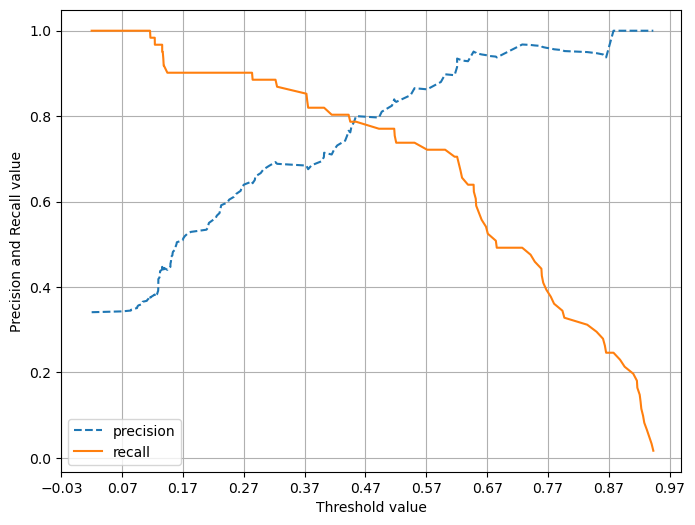

In [70]:
def precision_recall_curve_plot(y_test, pred_proba_c1):
    # threshold ndarray와 이 threshold에 따른 정밀도, 재현율 ndarray 추출.
    precisions, recalls, thresholds = precision_recall_curve( y_test, pred_proba_c1)

    # X축을 threshold값으로, Y축은 정밀도, 재현율 값으로 각각 Plot 수행. 정밀도는 점선으로 표시
    plt.figure(figsize=(8, 6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary], label='recall')

    # threshold 값 X 축의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))

    # x축, y축 label과 legend, 그리고 grid 설정
    plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
    plt.legend(); plt.grid()
    plt.show()

precision_recall_curve_plot( y_test, lr_clf.predict_proba(X_test)[:, 1] )

- 임곗값이 낮을수록 많은 수의 양성 예측으로 인해 재현율 값이 극도로 높아지고 정밀도 값이 극도로 낮아짐
- 임곗값 0.45 지점에서 재현율과 정밀도 비슷해짐

### 정밀도와 재현율의 맹점
- 임곗값의 변경은 정밀도와 재현율 수치를 상호보완할 수 있는 수준에서 적용되어야 함
- 하나의 성능 지표 수치를 높이기 위한 수단으로 사용되어서는 안됨

#### 정밀도가 100% 되는 방법 - 사용하면 안됨
- 확실한 기준이 되는 경우만 Positive 나머지는 Negative로 예측
- ex) 환자가 80세 이상이고 비만이며 이전에 암진단을 받았고 암 세포의 크기가 상위 0.1% 이상이면 무조건 Positive, 다른 경우 Negative
- TP / (TP+FP) = 1 / (1+0)

#### 재현율이 100%가 되는 방법 - 사용하면 안됨
- 모든 환자를 Positive로 예측
- TP / (TP + FN) = 30 / (30+0)




## 04 F1 스코어
- 정밀도와 재현율 결합한 지표
- 정밀도와 재현율이 어느 한쪽으로 치우치지 않는 수치를 나타낼 때 상대적으로 높은 값
- f1_score() 라는 API 제공
> F1 = 2 / (1/recall + 1/precision) = 2 × (precision × recall) / (precision + recall)



In [71]:
y_test.head()

431    1
821    1
629    0
626    0
665    0
Name: Survived, dtype: int64

In [72]:
print(pred)

[1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0
 1 0 0 0 0 1 1 1 1 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 1
 0 0 0 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 0 1 0 1 0 0 1 1 0 1 0 1 0 0 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 1 0 1 0 0 1 1 0 0 0 0 1 0 0
 1 0 0 1 1 0 1 1 0 0 1 1 0 1 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0 0 1]


In [73]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, pred)
print('F1 스코어: {0:.4f}'.format(f1))

F1 스코어: 0.7966


In [74]:
# 타이타닉 생존자 예측에서 임곗값을 변화시키면서 F1 스코어를 포함한 평가 지표를 구함
# 이를 위해 `get_clf_eval()` 함수에 F1 스코어를 구하는 로직을 추가
def get_clf_eval(y_test, pred):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    # F1 스코어 추가
    f1 = f1_score(y_test, pred)
    print('오차 행렬')
    print(confusion)
    # f1 score print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1:{3:.4f}'.format(accuracy, precision, recall, f1))

thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]
pred_proba = lr_clf.predict_proba(X_test)
get_eval_by_threshold(y_test, pred_proba[:, 1].reshape(-1, 1), thresholds)

## get_eval_by_threshold 함수 앞에 만들어놓음
# from sklearn.preprocessing import Binarizer

# def get_eval_by_threshold(y_test, pred_proba_c1, thresholds):
#    # thresholds 리스트 객체 내의 값을 차례로 iteration하면서 Evaluation 수행
#    for custom_threshold in thresholds:
#        binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_c1)
#        custom_predict = binarizer.transform(pred_proba_c1)
#        print('임곗값:', custom_threshold)
#        get_clf_eval(y_test, custom_predict)

임곗값: 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197, F1:0.7576
임곗값: 0.45
오차 행렬
[[105  13]
 [ 13  48]]
정확도: 0.8547, 정밀도: 0.7869, 재현율: 0.7869, F1:0.7869
임곗값: 0.5
오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705, F1:0.7966
임곗값: 0.55
오차 행렬
[[111   7]
 [ 16  45]]
정확도: 0.8715, 정밀도: 0.8654, 재현율: 0.7377, F1:0.7965
임곗값: 0.6
오차 행렬
[[113   5]
 [ 17  44]]
정확도: 0.8771, 정밀도: 0.8980, 재현율: 0.7213, F1:0.8000


- F1 스코어는 임곗값이 0.6일 때 가장 좋은 값을 보여주지만, 임곗값이 0.6인 경우에는 재현율이 크게 감소하고 있으니 주의

| 평가 지표 | 0.4 | 0.45 | 0.5 | 0.55 | 0.6 |
|---|---|---|---|---|---|
| 정확도 | 0.8212 | 0.8547 | 0.8659 | 0.8715 | 0.8771 |
| 정밀도 | 0.7042 | 0.7869 | 0.8246 | 0.8654 | 0.8980 |
| 재현율 | 0.8197 | 0.7869 | 0.7705 | 0.7377 | 0.7213 |
| F1 | 0.7576 | 0.7869 | 0.7966 | 0.7965 | 0.800 |

## ROC 곡선과 AUC
- 이진 분류의 예측 성능 측정에서 중요하게 사용되는 지표
- ROC : Receiver Operation Characteristic Curve로 수신자 판단 곡선
- 일반적으로 의학 분야에서 많이 사용
- FPR(False Positive Rate)이 변할 떄 TPR(True Positive Rate-재현율(민감도))이 어떻게 변하는지를 나타내는 곡선
- X축 : FPR / 축 : TPR
- TPR = TP / (FN + TP)
- TNR(True Negative Rate-특이도)
- TNR = TN / (FP + TN)
- 민감도(TPR) 실제값 Positive가 정확히 예측돼야하는 수준(질병이 있는 사람은 질병이 있는 것으로 양성 판정)
- 특이도(TNR) 실제값 Negative가 정확히 예측돼야하는 수준(질병이 없는 건강한 사람은 질병이 없는 것으로 음성 판정)

- roc_curve() API 제공
- 사용법은 `precision_recall_curve()`와 유사하고, 반환값이 FPR, TPR, 임곗값으로 구성된다는 점만 다름

In [75]:
from sklearn.metrics import roc_curve

# 레이블 값이 1일때의 예측 확률을 추출
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]

fprs , tprs , thresholds = roc_curve(y_test, pred_proba_class1)
# 반환된 임곗값 배열에서 샘플로 데이터를 추출하되, 임곗값을 5 Step으로 추출.
# thresholds[0]은 max(예측확률)+1로 임의 설정됨. 이를 제외하기 위해 np.arange는 1부터 시작
thr_index = np.arange(1, thresholds.shape[0], 5)

print('샘플 추출을 위한 임곗값 배열의 index:', thr_index)
print('샘플 index로 추출한 임곗값: ', np.round(thresholds[thr_index], 2))

# 5 step 단위로 추출된 임계값에 따른 FPR, TPR 값
print('샘플 임곗값별 FPR: ', np.round(fprs[thr_index], 3))
print('샘플 임곗값별 TPR: ', np.round(tprs[thr_index], 3))

샘플 추출을 위한 임곗값 배열의 index: [ 1  6 11 16 21 26 31 36 41 46]
샘플 index로 추출한 임곗값:  [0.94 0.73 0.62 0.52 0.44 0.28 0.15 0.14 0.13 0.12]
샘플 임곗값별 FPR:  [0.    0.008 0.025 0.076 0.127 0.254 0.576 0.61  0.746 0.847]
샘플 임곗값별 TPR:  [0.016 0.492 0.705 0.738 0.803 0.885 0.902 0.951 0.967 1.   ]


- 임곗값이 1에 가까운 값에서 점점 작아지면서 FPR 점점 커짐
- FPR이 조금씩 커질 때 TPR을 가파르게 커짐


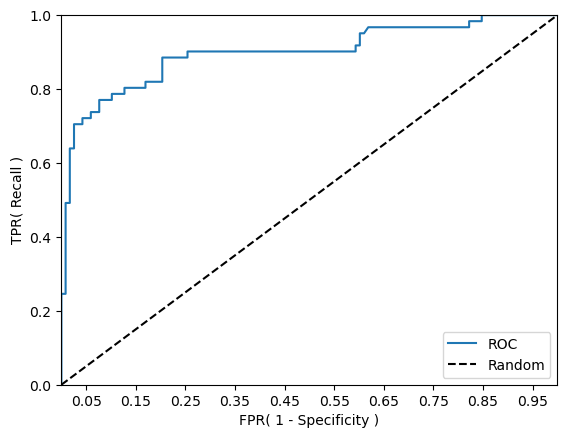

In [76]:
# 시각화
def roc_curve_plot(y_test, pred_proba_c1):
    # 임곗값에 따른 FPR, TPR 값을 반환받음.
    fprs, tprs, thresholds = roc_curve(y_test, pred_proba_c1)
    # ROC 곡선을 그래프 곡선으로 그림.
    plt.plot(fprs, tprs, label='ROC')
    # 가운데 대각선 직선을 그림.
    plt.plot([0, 1], [0, 1], 'k--', label='Random')

    # FPR X 축의 Scale을 0.1 단위로 변경, X, Y축 명 설정 등
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))
    plt.xlim(0, 1); plt.ylim(0, 1)
    plt.xlabel('FPR( 1 - Specificity )'); plt.ylabel('TPR( Recall )')
    plt.legend()

roc_curve_plot(y_test, pred_proba[:, 1] )
plt.show()

- AUC 값: ROC 곡선 밑의 면적을 구한 것, 1에 가까울수록 좋은 수치
- AUC가 커지려면 FPR이 작은 상태에서 얼마나 큰 TPR을 얻을 수 있느냐가 관건
- 가운데 대각선 직선응ㄴ 랜덤 수준의(동전 던지기 수준) 이진 분류 AUC 값으로 0.5
- 보통은 0.5이상의 AUC값 가짐



In [77]:
X_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
431,3,0,29.699118,1,0,16.1000,7,3
821,3,1,27.000000,0,0,8.6625,7,3
629,3,1,29.699118,0,0,7.7333,7,2
626,2,1,57.000000,0,0,12.3500,7,2
665,2,1,32.000000,2,0,73.5000,7,3


In [78]:
# 타이타닉 생존자 예측 로지스틱 회귀 모델의 ROC AUC 값
from sklearn.metrics import roc_auc_score

pred_proba = lr_clf.predict_proba(X_test)[:, 1]
roc_score = roc_auc_score(y_test, pred_proba)
print('ROC AUC 값: {0:.4f}'.format(roc_score))

ROC AUC 값: 0.8987


In [79]:
# Positive(1)일 확률
pred_proba

array([0.55064775, 0.13664489, 0.13570357, 0.15031481, 0.17656591,
       0.15768776, 0.12904511, 0.72771397, 0.21814872, 0.66814001,
       0.13821236, 0.12941903, 0.1357405 , 0.12934056, 0.43966456,
       0.14996978, 0.11045828, 0.25749268, 0.28879776, 0.76223721,
       0.24315893, 0.37571831, 0.15344754, 0.17288744, 0.13174372,
       0.22996172, 0.17053651, 0.09663869, 0.26627951, 0.31152613,
       0.92353131, 0.7746788 , 0.12838061, 0.75924582, 0.3728827 ,
       0.22996172, 0.09445724, 0.59397426, 0.06956416, 0.1234948 ,
       0.30202578, 0.10335405, 0.78006621, 0.68434287, 0.62057772,
       0.62067109, 0.92838719, 0.44222412, 0.92085513, 0.13196918,
       0.49209943, 0.12934056, 0.14423595, 0.65129871, 0.28441583,
       0.21146794, 0.2538079 , 0.13571   , 0.15920997, 0.40161934,
       0.26467919, 0.11294404, 0.454472  , 0.44673656, 0.37416478,
       0.11636723, 0.64818744, 0.60096648, 0.91699185, 0.14927478,
       0.13221181, 0.16929076, 0.12350958, 0.94040085, 0.21264

In [81]:
# get_clf_eval() 함수에 roc_auc_score()을 이용해 ROC AUC 값 측정하는 로직 추가
# get_clf_eval() 함수의 인자로 받을 수 있도록 get_clf_eval(y_test, pred=None, pred_proba=None)으로 함수형 변경
# get_clf_eval() 함수는 정확도, 정밀도, 재현율, F1 스코어, ROC AUC 값까지 출력
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
        F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

## 06 피마 인디언 당뇨병 예측
- 피마 인디언 당뇨병 데이터 세트 : 북아메리카 피마 지역 원주민의 Type-2 당뇨병 결과 데이터
- 피마 지역은 고립된 지역에서 인디언 고유의 혈통이 지속되어왔지만 20세기 후반에 들어서면서 서구화된 식습관으로 많은 당뇨환자가 생겨남

- Pregnancies: 임신 횟수
- Glucose: 포도당 부하 검사 수치
- BloodPressure: 혈압(mm Hg)
- SkinThickness: 팔 삼두근 뒤쪽의 피하지방 측정값(mm)
- Insulin: 혈청 인슐린(mu U/ml)
- BMI: 체질량지수(체중(kg)/(키(m))^2)
- DiabetesPedigreeFunction: 당뇨 내력 가중치 값
- Age: 나이
- Outcome: 클래스 결정 값(0 또는 1)




In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler

In [86]:
# 1이면 당뇨
from sklearn.linear_model import LogisticRegression

diabetes_data = pd.read_csv('diabetes.csv')
print(diabetes_data['Outcome'].value_counts())
diabetes_data.head(3)

Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


- Negative 500개 Positive 268개로 Negative가 상대적으로 많음

In [87]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


- Null 값 없으며 피처의 타입은 모두 숫자형

In [89]:
# 로지스틱 회귀를 이용해 예측 보델 생성
# 피처 데이터 세트 / 클래스 데이터 세트로 나눔 + 학습 데이터 세트 / 테스트 데이터 세트로 분리

# 피처 데이터 세트 X, 레이블 데이터 세트 y를 추출.
# 맨 끝이 Outcome 칼럼으로 레이블 값임. 칼럼 위치 -1을 이용해 추출
X = diabetes_data.iloc[:, :-1]
y = diabetes_data.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 156, stratify=y)

# 로지스틱 회귀로 학습, 예측 및 평가 수행.
lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, pred, pred_proba)

오차 행렬
[[87 13]
 [22 32]]
정확도: 0.7727, 정밀도: 0.7111, 재현율: 0.5926,        F1: 0.6465, AUC:0.8083


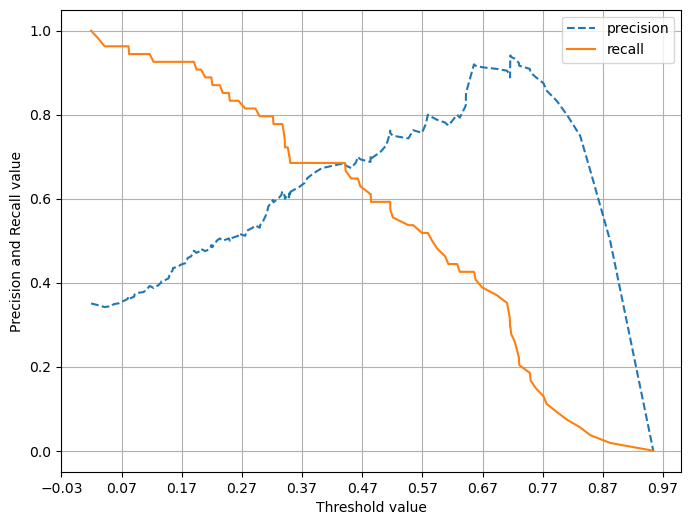

In [90]:
# 전체 데이터가 65%가 Negatie이므로 정확도보다 재현율 성능에 조금 더 초점을 맞춤
# 정밀도 재현율 곡선을 보고 임곗값별 정밀도와 재현율 값의 변환 확인
pred_proba_c1 = lr_clf.predict_proba(X_test)[:, 1]
precision_recall_curve_plot(y_test, pred_proba_c1)

- 재현율 곡선을 보면 임곗값을 0.42 정도로 낮추면 정밀도와 재현율이 어느정도 균형을 이룸
- 그러나 두 지표 모두 0.7이 안되는 수치 => 값이 낮음




In [92]:
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


- min() 값이 0으로 되어있는 피처가 상당히 많음
- ex) Glucose(포도당수치) min값이 0인 것은 말이 안됨


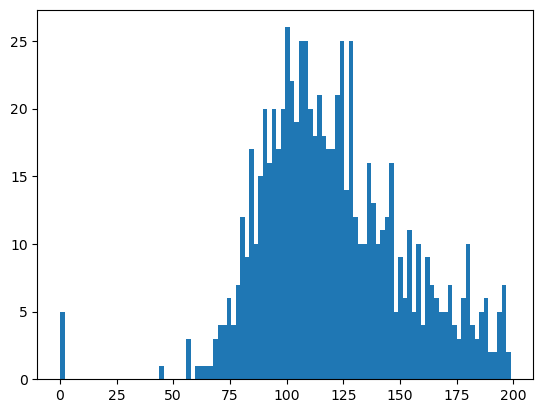

In [94]:
# 히스토그램으로 Glucose 확인
plt.hist(diabetes_data['Glucose'], bins=100)
plt.show()

- 0값이 5개 존재
+ 다른 피처도 확인(Pregnancies는 출산횟수이기 떄문에 0이 가능하므로 제외)

In [95]:
# 0값을 검사할 피처명 리스트
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 전체 데이터 건수
total_count = diabetes_data['Glucose'].count()

# 피처별로 반복하면서 데이터 값이 0인 데이터 건수를 추출하고, 퍼센트 계산
for feature in zero_features:
    zero_count = diabetes_data[diabetes_data[feature] == 0][feature].count()
    print('{0} 0 건수는 {1}, 퍼센트는 {2:.2f} %'.format(feature, zero_count,
                                                   100*zero_count/total_count))

Glucose 0 건수는 5, 퍼센트는 0.65 %
BloodPressure 0 건수는 35, 퍼센트는 4.56 %
SkinThickness 0 건수는 227, 퍼센트는 29.56 %
Insulin 0 건수는 374, 퍼센트는 48.70 %
BMI 0 건수는 11, 퍼센트는 1.43 %


- SkinThickness와 Insulin의 0값은 각각 전체의 29.56%, 48.7%로 많음
- 전체 데이터 건수가 많지 않기 때문에 삭제하는 방법을 쓸 경우 학습이 어려움
=> 위 피처의 0값을 평균값으로 대체



In [97]:
# zero_features 리스트 내부에 저장된 개별 피처들에 대해서 0값을 평균 값으로 대체
mean_zero_features = diabetes_data[zero_features].mean()
diabetes_data[zero_features]=diabetes_data[zero_features].replace(0, mean_zero_features)

In [98]:
# 다시 학습/테스트 데이터 나누고 로지스틱 회귀를 적용해 성능 평가 지표 확인
X = diabetes_data.iloc[:, :-1]
y = diabetes_data.iloc[:, -1]

# StandardScaler 클래스를 이용해 피처 데이터 세트에 일괄적으로 스케일링 적용
# 변수의 중요도와 상관없이 단위 때문에 어떤 변수는 손해를 보고 어떤 변수는 이득을 봄
# 표준화하면 모든 피처가 같은 단위가 돼서 벌점이 공평하게 적용
scaler = StandardScaler( )
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 156, stratify=y)

# 로지스틱 회귀로 학습, 예측 및 평가 수행.
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, pred, pred_proba)

오차 행렬
[[90 10]
 [21 33]]
정확도: 0.7987, 정밀도: 0.7674, 재현율: 0.6111,        F1: 0.6804, AUC:0.8433


- 성능 수치 일정 수준 개선됨
- 재현율 수치는 여전히 낮음



In [100]:
from sklearn.preprocessing import Binarizer

def get_eval_by_threshold(y_test, pred_proba_c1, thresholds):
    for custom_threshold in thresholds:
        binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_c1)
        custom_predict = binarizer.transform(pred_proba_c1)
        print('임곗값:', custom_threshold)
        get_clf_eval(y_test, custom_predict, pred_proba_c1)

In [102]:
# 임곗값 조절하며 재현율과 다른 평가 지표 값 변화 살펴보기
thresholds = [0.3, 0.33, 0.36, 0.39, 0.42, 0.45, 0.48, 0.50]
pred_proba = lr_clf.predict_proba(X_test)
get_eval_by_threshold(y_test, pred_proba[:, 1].reshape(-1, 1), thresholds )

임곗값: 0.3
오차 행렬
[[67 33]
 [11 43]]
정확도: 0.7143, 정밀도: 0.5658, 재현율: 0.7963,        F1: 0.6615, AUC:0.8433
임곗값: 0.33
오차 행렬
[[72 28]
 [12 42]]
정확도: 0.7403, 정밀도: 0.6000, 재현율: 0.7778,        F1: 0.6774, AUC:0.8433
임곗값: 0.36
오차 행렬
[[76 24]
 [15 39]]
정확도: 0.7468, 정밀도: 0.6190, 재현율: 0.7222,        F1: 0.6667, AUC:0.8433
임곗값: 0.39
오차 행렬
[[78 22]
 [16 38]]
정확도: 0.7532, 정밀도: 0.6333, 재현율: 0.7037,        F1: 0.6667, AUC:0.8433
임곗값: 0.42
오차 행렬
[[84 16]
 [18 36]]
정확도: 0.7792, 정밀도: 0.6923, 재현율: 0.6667,        F1: 0.6792, AUC:0.8433
임곗값: 0.45
오차 행렬
[[85 15]
 [18 36]]
정확도: 0.7857, 정밀도: 0.7059, 재현율: 0.6667,        F1: 0.6857, AUC:0.8433
임곗값: 0.48
오차 행렬
[[88 12]
 [19 35]]
정확도: 0.7987, 정밀도: 0.7447, 재현율: 0.6481,        F1: 0.6931, AUC:0.8433
임곗값: 0.5
오차 행렬
[[90 10]
 [21 33]]
정확도: 0.7987, 정밀도: 0.7674, 재현율: 0.6111,        F1: 0.6804, AUC:0.8433


- 0.48전체적인 성능 평가지표를 유지하면서 재현율을 약간 향상시키는 좋은 임곗값

In [104]:
# 임곗값 0.48로 낮춘 상태에서 다시 예측
# 임곗값을 0.48로 설정한 Binarizer 생성
binarizer = Binarizer(threshold=0.48)

# 위에서 구한 lr_clf의 predict_proba() 예측 확률 array에서 1에 해당하는 칼럼값을 Binarizer 변환.
pred_th_048 = binarizer.fit_transform(pred_proba[:, 1].reshape(-1, 1))

get_clf_eval(y_test, pred_th_048, pred_proba[:, 1])

오차 행렬
[[88 12]
 [19 35]]
정확도: 0.7987, 정밀도: 0.7447, 재현율: 0.6481,        F1: 0.6931, AUC:0.8433


## 07 정리
### 오차행렬
- 실제 클래스 값과 예측 클래스 값이 True/False에 따라 TN, FP, FN, TP로 매핑되는 4분면 행렬을 기반으로 예측 성능을 평가
- 정확도, 정밀도, 재현율 수치는 TN, FP, FN, TP 값을 다양하게 결합해 만들어지며, 이를 통해 분류 모델 예측 성능의 오류가 어떠한 모습으로 발생하는지 알 수 있음

### 정밀도와 재현율
- 데이터 세트의 예측 성능에 좀 더 초점을 맞춘 평가 지표
- 특히 재현율이 상대적으로 더 중요한 지표인 경우는 암 양성 예측 모델과 같이 실제 Positive 양성인 데이터를 Negative로 잘못 판단하게 되면 업무상 큰 영향이 발생하는 경우
- 분류하려는 업무의 특성상 정밀도 또는 재현율이 특별히 강조돼야 할 경우 분류의 결정 임곗값(Threshold)을 조정해 정밀도 또는 재현율의 수치를 높일 수 있음

### F1 스코어
- 정밀도와 재현율을 결합한 평가 지표
- 정밀도와 재현율이 어느 한쪽으로 치우치지 않을 때 높은 지표값을 가지게 됨
- ROC-AUC는 일반적으로 이진 분류의 성능 평가를 위해 가장 많이 사용되는 지표
- AUC(Area Under Curve) 값은 ROC 곡선 밑의 면적을 구한 것으로서 일반적으로 1에 가까울수록 좋은 수치
